# Predicting House Prices with Linear Regression

**Level 2 — Task 1 | Data Analytics Internship Project**

This notebook builds and evaluates an end-to-end house-price regression workflow using a public Kaggle dataset. It covers exploratory data analysis, feature reasoning, missing-value handling, one-hot encoding, correlation analysis, an 80/20 train-test split, Linear Regression, residual diagnostics, coefficient interpretation, and a Ridge Regression comparison.

**Dataset source:** [Housing Prices Dataset on Kaggle](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)  
**Original file:** `Housing.csv`  
**Rows:** 545 | **Columns:** 13 | **Target:** `price`


## TL;DR

- The Kaggle dataset contains **545 houses**, **12 predictors**, no missing values, and no duplicate rows.
- The target is right-skewed (**skewness = 1.21**), with a few high-price properties that are difficult for a straight-line model.
- On the fixed 20% test set, Linear Regression achieved **R² = 0.653** and **RMSE = 1,324,507 price units**.
- Ridge selected **alpha = 6.251** but produced **R² = 0.648**, so it did not beat ordinary Linear Regression on this split.
- Residual size rises moderately with predicted price (**correlation = 0.32**), and the most expensive homes tend to be underpredicted. Treat the model as an interpretable baseline rather than a production valuation system.


## Context & Methods

### Objective

Predict house prices from structural and amenity features while keeping the model transparent enough to explain which factors are associated with higher or lower prices.

### Key assumptions

- Each row represents one house and observations are treated as independent.
- `price` is modeled in the dataset's original price units.
- `prefarea` is used as a broad location-related proxy; the dataset does not provide a neighborhood name or exact geographic location.
- The dataset does not contain construction year or property age, so age cannot be evaluated without inventing information.
- Coefficients describe model associations, not causal effects.
- The same random 80/20 split (`random_state=42`) is used for fair model comparison.


## Data


### 1. Import libraries and set presentation defaults

The workflow uses pandas for data handling, seaborn/matplotlib for charts, and scikit-learn pipelines so preprocessing is learned only from the training data.


In [1]:
from pathlib import Path
import io
import urllib.request
import zipfile
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

NAVY = "#17324D"
EMERALD = "#148F77"
GOLD = "#C99820"
CORAL = "#C85C5C"
LIGHT_GREY = "#E7EBEF"

def millions(value, _position=None):
    return f"{value / 1_000_000:.1f}M"


mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-9y6_cgz7 because there was an issue with the default path (/root/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


### 2. Load the Kaggle dataset

The notebook first looks for `Housing.csv` beside the notebook. If it is missing, it downloads the same public Kaggle archive and extracts the CSV. Keeping the included CSV beside the notebook is recommended for offline execution.


In [2]:
DATA_PATH = Path("Housing.csv")
KAGGLE_DATASET_PAGE = "https://www.kaggle.com/datasets/yasserh/housing-prices-dataset"
KAGGLE_DOWNLOAD_URL = "https://www.kaggle.com/api/v1/datasets/download/yasserh/housing-prices-dataset"

if not DATA_PATH.exists():
    print("Housing.csv not found locally; downloading the public Kaggle archive...")
    with urllib.request.urlopen(KAGGLE_DOWNLOAD_URL, timeout=60) as response:
        archive_bytes = response.read()
    with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
        archive.extract("Housing.csv", path=DATA_PATH.parent)

housing = pd.read_csv(DATA_PATH)
print(f"Loaded {housing.shape[0]:,} rows and {housing.shape[1]} columns from {DATA_PATH.resolve()}")
print(f"Kaggle source: {KAGGLE_DATASET_PAGE}")
print("\nFirst five rows:")
print(housing.head().to_string(index=False))


Loaded 545 rows and 13 columns from /workspace/scratch/ab4dab6b3a93/house-price-linear-regression/Housing.csv
Kaggle source: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

First five rows:
   price  area  bedrooms  bathrooms  stories mainroad guestroom basement hotwaterheating airconditioning  parking prefarea furnishingstatus
13300000  7420         4          2        3      yes        no       no              no             yes        2      yes        furnished
12250000  8960         4          4        4      yes        no       no              no             yes        3       no        furnished
12250000  9960         3          2        2      yes        no      yes              no              no        2      yes   semi-furnished
12215000  7500         4          2        2      yes        no      yes              no             yes        3      yes        furnished
11410000  7420         4          1        2      yes       yes      yes              no      

### 3. Inspect structure, data types, nulls, and duplicates


In [3]:
print("Dataset information:")
housing.info()

quality_summary = pd.DataFrame({
    "data_type": housing.dtypes.astype(str),
    "missing_count": housing.isna().sum(),
    "missing_percent": housing.isna().mean().mul(100),
    "unique_values": housing.nunique()
})

print("\nColumn quality summary:")
print(quality_summary.to_string())
print(f"\nDuplicate rows: {housing.duplicated().sum():,}")


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Column quality summary:
                 data_type  missing_count  missing_percent  unique_values
price                int64        

### 4. Descriptive statistics


In [4]:
print("Numeric features:")
print(housing.describe().T.to_string())

print("\nCategorical features:")
print(housing.describe(include="object").T.to_string())


Numeric features:
           count         mean          std          min          25%          50%          75%           max
price     545.00 4,766,729.25 1,870,439.62 1,750,000.00 3,430,000.00 4,340,000.00 5,740,000.00 13,300,000.00
area      545.00     5,150.54     2,170.14     1,650.00     3,600.00     4,600.00     6,360.00     16,200.00
bedrooms  545.00         2.97         0.74         1.00         2.00         3.00         3.00          6.00
bathrooms 545.00         1.29         0.50         1.00         1.00         1.00         2.00          4.00
stories   545.00         1.81         0.87         1.00         1.00         2.00         2.00          4.00
parking   545.00         0.69         0.86         0.00         0.00         0.00         1.00          3.00

Categorical features:
                 count unique             top freq
mainroad           545      2             yes  468
guestroom          545      2              no  448
basement           545      2              

### 5. Target-variable distribution

A histogram with a density curve reveals whether prices are symmetric or skewed. Strong skew or extreme values can make ordinary least squares less accurate at the expensive end of the market.


Mean price:   4,766,729
Median price: 4,340,000
Skewness:     1.212


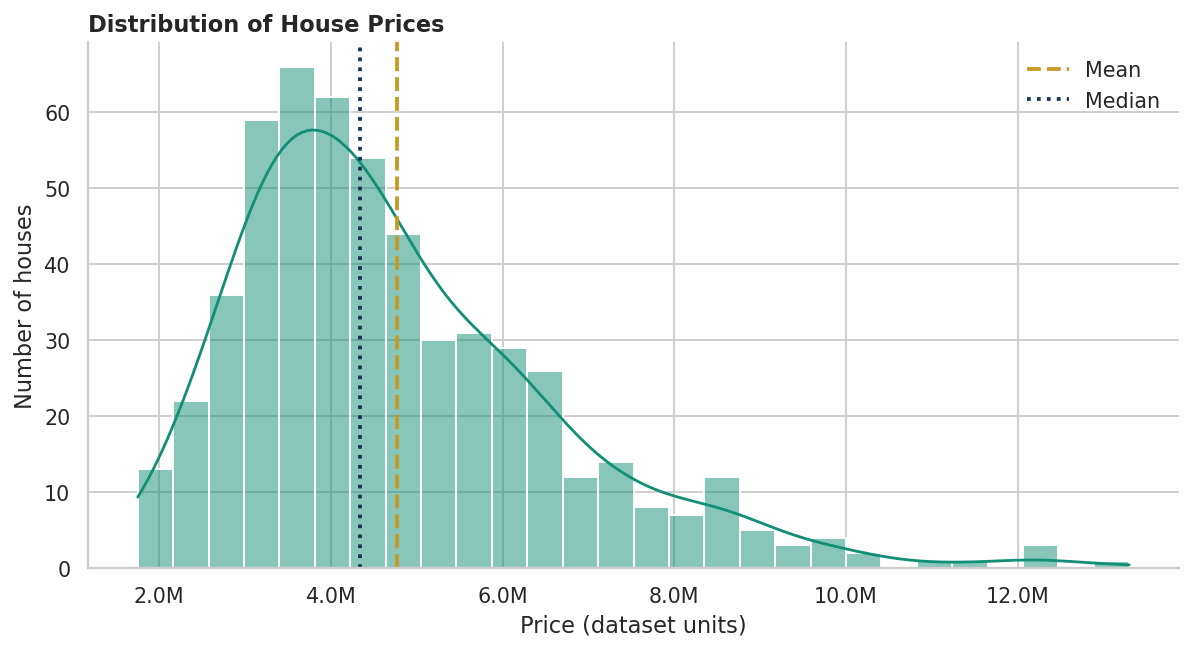

In [5]:
price_skewness = housing["price"].skew()
print(f"Mean price:   {housing['price'].mean():,.0f}")
print(f"Median price: {housing['price'].median():,.0f}")
print(f"Skewness:     {price_skewness:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(housing["price"], bins=28, kde=True, color=EMERALD, edgecolor="white", ax=ax)
ax.axvline(housing["price"].mean(), color=GOLD, linestyle="--", linewidth=2, label="Mean")
ax.axvline(housing["price"].median(), color=NAVY, linestyle=":", linewidth=2, label="Median")
ax.set_title("Distribution of House Prices", loc="left", fontweight="bold")
ax.set_xlabel("Price (dataset units)")
ax.set_ylabel("Number of houses")
ax.xaxis.set_major_formatter(FuncFormatter(millions))
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()


### 6. Feature-selection discussion

All 12 available predictors are retained because each has a reasonable connection to price:

- **Size and capacity:** `area`, `bedrooms`, `bathrooms`, `stories`, and `parking` describe how much usable space or capacity a house offers.
- **Access and location proxy:** `mainroad` and `prefarea` may capture accessibility and broad location desirability.
- **Amenities:** `guestroom`, `basement`, `hotwaterheating`, and `airconditioning` may add comfort or utility.
- **Finish:** `furnishingstatus` can affect the price at which a house is offered.

No identifier column is present. Exact location and house age are unavailable, so the analysis explicitly avoids fabricating them. Feature selection is performed before the split only at the conceptual level; all learned preprocessing remains inside the training pipeline.


### 7. Correlation analysis

For exploratory correlation only, categorical variables are one-hot encoded. The heatmap is limited to the ten predictors with the largest absolute correlation with `price`, keeping it readable. Correlation is descriptive and does not prove causation.


Features most correlated with price:
                              correlation_with_price
area                                            0.54
bathrooms                                       0.52
airconditioning_yes                             0.45
stories                                         0.42
parking                                         0.38
bedrooms                                        0.37
prefarea_yes                                    0.33
mainroad_yes                                    0.30
furnishingstatus_unfurnished                   -0.28
guestroom_yes                                   0.26
basement_yes                                    0.19
hotwaterheating_yes                             0.09


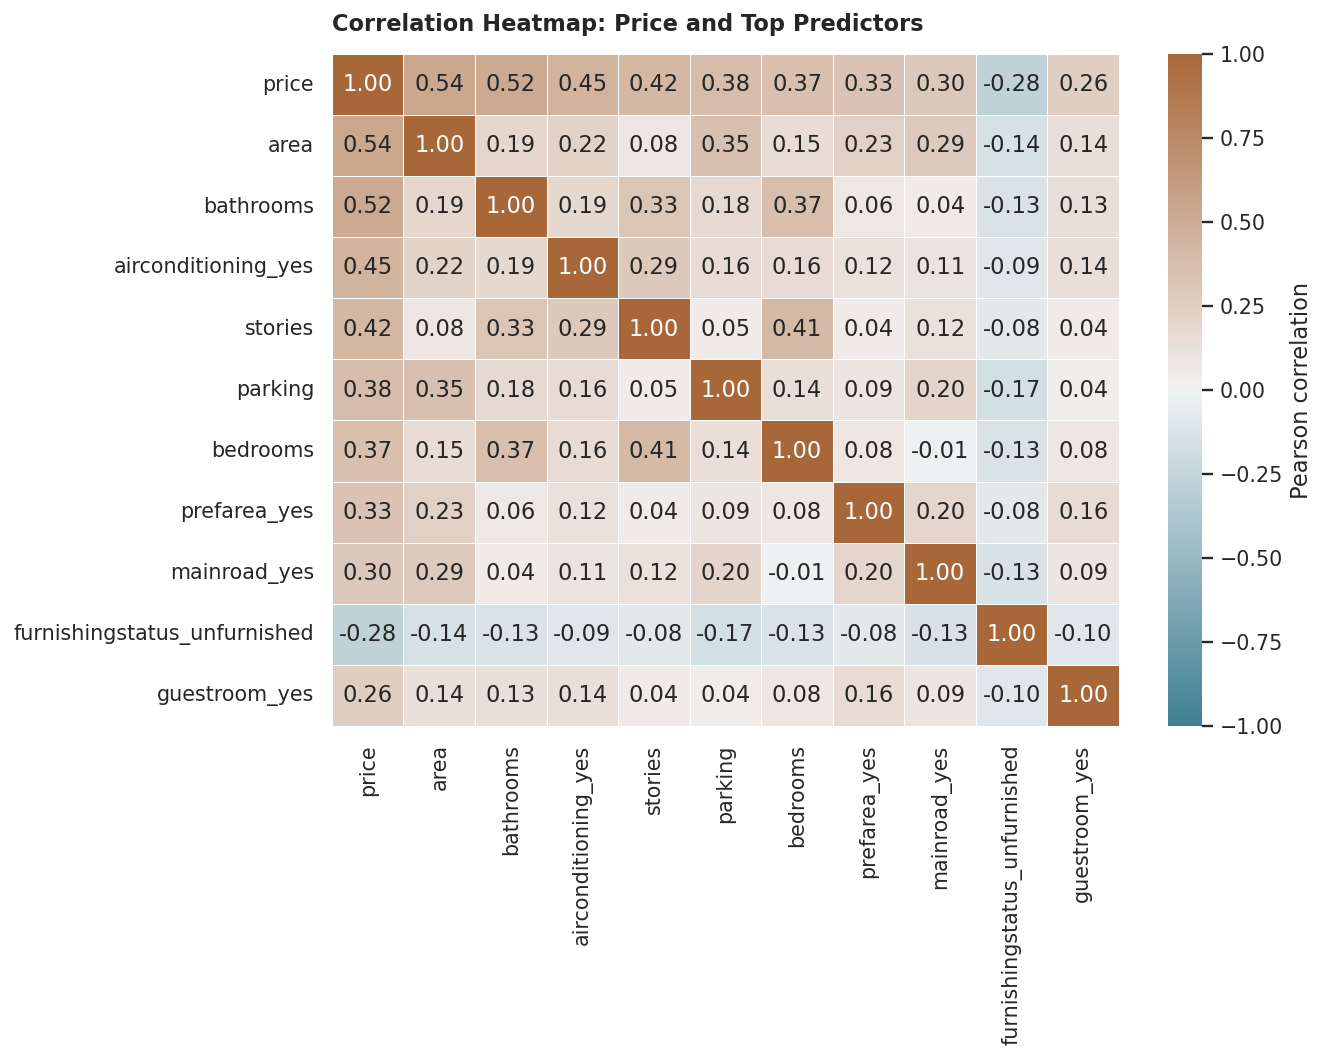

In [6]:
correlation_data = pd.get_dummies(housing, drop_first=True, dtype=int)
correlation_matrix = correlation_data.corr()
target_correlations = (
    correlation_matrix["price"]
    .drop("price")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

print("Features most correlated with price:")
print(target_correlations.head(12).to_frame("correlation_with_price").to_string())

top_correlation_features = target_correlations.head(10).index.tolist()
heatmap_columns = ["price"] + top_correlation_features

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix.loc[heatmap_columns, heatmap_columns],
    cmap=sns.diverging_palette(220, 35, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Correlation Heatmap: Price and Top Predictors", loc="left", fontweight="bold", pad=12)
plt.tight_layout()


## Results


### 8. Prepare features and make an 80/20 split

Missing numeric values are imputed with the median, categorical values with the most frequent category, and categorical variables are one-hot encoded. Numeric predictors are standardized so the coefficient magnitudes are comparable and Ridge regularization is well behaved. The current dataset has no nulls, but the pipeline remains safe if future rows contain them.


In [7]:
TARGET = "price"
X = housing.drop(columns=TARGET)
y = housing[TARGET]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Numeric predictors ({len(numeric_features)}): {numeric_features}")
print(f"Categorical predictors ({len(categorical_features)}): {categorical_features}")
print(f"Training rows: {len(X_train):,} ({len(X_train) / len(X):.0%})")
print(f"Testing rows:  {len(X_test):,} ({len(X_test) / len(X):.0%})")

def make_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            drop="first", handle_unknown="ignore", sparse_output=False
        )),
    ])
    return ColumnTransformer(transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


Numeric predictors (5): ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical predictors (7): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Training rows: 436 (80%)
Testing rows:  109 (20%)


### 9. Train the Linear Regression model


In [8]:
linear_model = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
print("Linear Regression training complete.")


Linear Regression training complete.


### 10. Evaluate with MSE, RMSE, and R²

- **MSE** averages squared errors and heavily penalizes large misses.
- **RMSE** is the square root of MSE and is expressed in the original price units.
- **R²** is the share of test-set price variance explained by the model; higher is better.


In [9]:
def regression_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(actual, predicted),
    }

linear_metrics = regression_metrics(y_test, linear_predictions)

print("Linear Regression test metrics")
print(f"MSE:  {linear_metrics['MSE']:,.2f}")
print(f"RMSE: {linear_metrics['RMSE']:,.2f}")
print(f"R²:   {linear_metrics['R2']:.4f}")


Linear Regression test metrics
MSE:  1,754,318,687,330.67
RMSE: 1,324,506.96
R²:   0.6529


### 11. Actual versus predicted prices

Points close to the diagonal reference line represent accurate predictions. Larger vertical gaps indicate larger prediction errors.


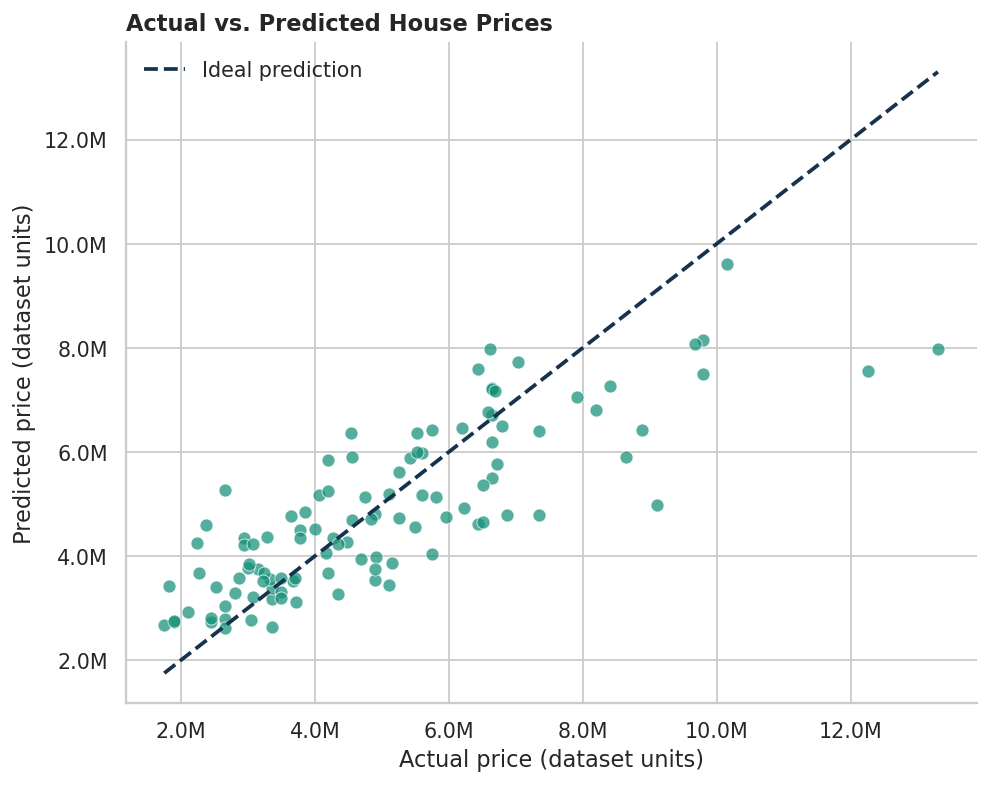

In [10]:
comparison = pd.DataFrame({
    "actual_price": y_test.to_numpy(),
    "predicted_price": linear_predictions,
})

minimum_price = min(comparison.min())
maximum_price = max(comparison.max())

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(
    comparison["actual_price"],
    comparison["predicted_price"],
    color=EMERALD,
    alpha=0.72,
    s=48,
    edgecolor="white",
    linewidth=0.5,
)
ax.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    color=NAVY,
    linestyle="--",
    linewidth=2,
    label="Ideal prediction",
)
ax.set_title("Actual vs. Predicted House Prices", loc="left", fontweight="bold")
ax.set_xlabel("Actual price (dataset units)")
ax.set_ylabel("Predicted price (dataset units)")
ax.xaxis.set_major_formatter(FuncFormatter(millions))
ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()


### 12. Residual diagnostics

A good linear model should show residuals scattered around zero without a clear curve or funnel. Residuals are calculated as `actual − predicted`, so positive values mean the model underpredicted the price.


Mean residual: 146,055.36
Correlation(prediction, residual): 0.222
Correlation(prediction, |residual|): 0.320


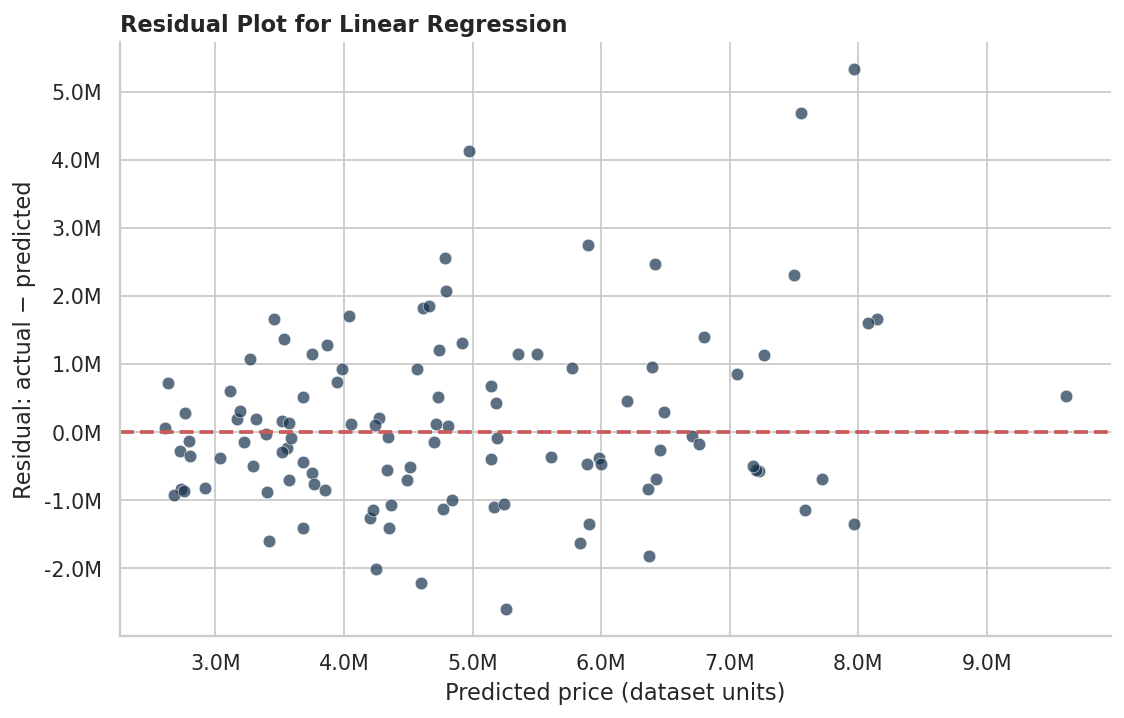

In [11]:
residuals = y_test.to_numpy() - linear_predictions
residual_mean = residuals.mean()
residual_prediction_correlation = np.corrcoef(linear_predictions, residuals)[0, 1]
absolute_residual_correlation = np.corrcoef(linear_predictions, np.abs(residuals))[0, 1]

print(f"Mean residual: {residual_mean:,.2f}")
print(f"Correlation(prediction, residual): {residual_prediction_correlation:.3f}")
print(f"Correlation(prediction, |residual|): {absolute_residual_correlation:.3f}")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(
    linear_predictions,
    residuals,
    color=NAVY,
    alpha=0.70,
    s=45,
    edgecolor="white",
    linewidth=0.4,
)
ax.axhline(0, color=CORAL, linestyle="--", linewidth=2)
ax.set_title("Residual Plot for Linear Regression", loc="left", fontweight="bold")
ax.set_xlabel("Predicted price (dataset units)")
ax.set_ylabel("Residual: actual − predicted")
ax.xaxis.set_major_formatter(FuncFormatter(millions))
ax.yaxis.set_major_formatter(FuncFormatter(millions))
sns.despine()
plt.tight_layout()


### 13. Coefficient analysis

Numeric predictors were standardized, so a numeric coefficient estimates the price change associated with a one-standard-deviation increase while other features are held constant. Categorical coefficients compare a category with its dropped reference category (`no` for binary fields and `furnished` for furnishing status). Coefficients are associations within this model, not causal effects.


Largest negative coefficients:
                        feature  coefficient
   furnishingstatus_unfurnished  -413,645.06
furnishingstatus_semi-furnished  -126,881.82
                       bedrooms    57,349.56
                        parking   192,005.95
                  guestroom_yes   231,610.04

Largest positive coefficients:
            feature  coefficient
airconditioning_yes   791,426.74
hotwaterheating_yes   684,649.89
       prefarea_yes   629,890.57
          bathrooms   521,879.03
               area   519,552.42


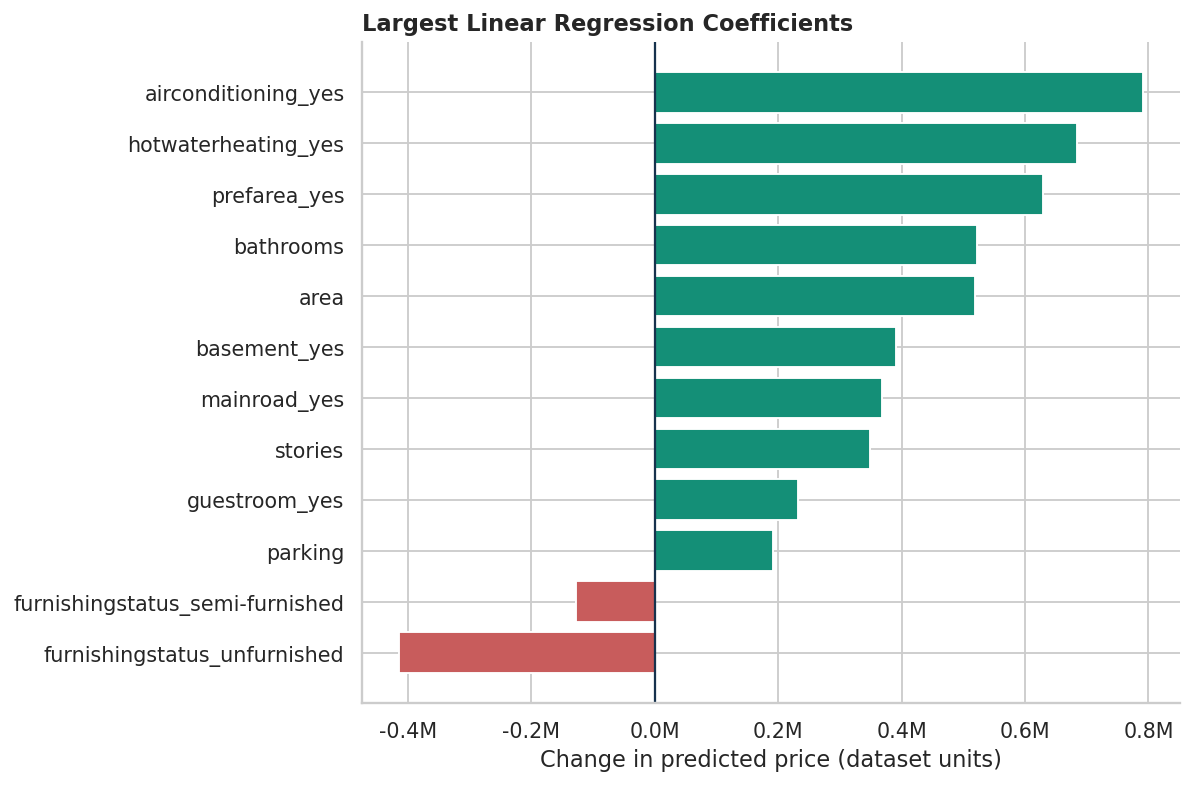

In [12]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in feature_names
]
coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": linear_model.named_steps["model"].coef_,
})
coefficients["absolute_impact"] = coefficients["coefficient"].abs()
coefficients = coefficients.sort_values("coefficient")

print("Largest negative coefficients:")
print(coefficients.head(5)[["feature", "coefficient"]].to_string(index=False))
print("\nLargest positive coefficients:")
print(coefficients.tail(5).sort_values("coefficient", ascending=False)[["feature", "coefficient"]].to_string(index=False))

top_coefficients = coefficients.nlargest(12, "absolute_impact").sort_values("coefficient")
coefficient_colors = [CORAL if value < 0 else EMERALD for value in top_coefficients["coefficient"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_coefficients["feature"], top_coefficients["coefficient"], color=coefficient_colors)
ax.axvline(0, color=NAVY, linewidth=1.2)
ax.set_title("Largest Linear Regression Coefficients", loc="left", fontweight="bold")
ax.set_xlabel("Change in predicted price (dataset units)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(millions))
sns.despine()
plt.tight_layout()


### 14. Bonus: compare with Ridge Regression

Ridge adds an L2 penalty that shrinks coefficients and can improve generalization when predictors overlap. `RidgeCV` selects the penalty strength from a logarithmic grid using five-fold cross-validation on the training set only.


In [13]:
ridge_model = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)),
])

ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)
ridge_metrics = regression_metrics(y_test, ridge_predictions)

metrics_comparison = pd.DataFrame([
    {"Model": "Linear Regression", **linear_metrics},
    {"Model": "Ridge Regression", **ridge_metrics},
])

print(f"Selected Ridge alpha: {ridge_model.named_steps['model'].alpha_:.4f}")
print("\nModel comparison:")
print(metrics_comparison.to_string(index=False, formatters={
    "MSE": lambda value: f"{value:,.2f}",
    "RMSE": lambda value: f"{value:,.2f}",
    "R2": lambda value: f"{value:.4f}",
}))


Selected Ridge alpha: 6.2506

Model comparison:
            Model                  MSE         RMSE     R2
Linear Regression 1,754,318,687,330.67 1,324,506.96 0.6529
 Ridge Regression 1,778,832,738,127.60 1,333,728.88 0.6481


## Takeaways


### Interpretation and limitations

- The model provides a useful baseline, but the target distribution is right-skewed and the most expensive homes are often underpredicted.
- The residual plot shows some increase in error size at higher predicted prices, so the constant-variance assumption is imperfect.
- Ridge regularization does not materially improve the fixed test split, suggesting that coefficient shrinkage alone does not solve the remaining nonlinear behavior and omitted-feature problem.
- `airconditioning`, `prefarea`, `area`, `bathrooms`, and `hotwaterheating` are among the strongest positive associations in this fitted model. An `unfurnished` status has the strongest negative association relative to `furnished`.
- Exact neighborhood and property age are unavailable. Adding those features—and evaluating nonlinear models—would be sensible next steps, but they are outside the required Linear Regression scope.

### Checklist status

- ✅ Data load, null checks, duplicates, and descriptive statistics
- ✅ Target distribution
- ✅ Feature-selection discussion
- ✅ Missing-value handling and One-Hot Encoding
- ✅ Correlation heatmap
- ✅ 80/20 train-test split
- ✅ Linear Regression
- ✅ MSE, RMSE, and R²
- ✅ Actual-versus-predicted scatter plot
- ✅ Residual plot
- ✅ Coefficient analysis
- ✅ Bonus Ridge comparison
